# Assignment 11: Matplotlib (Core Plot Types & Visualization)

## Task 1: Line Plot (Sales Trend)

In [1]:
'''
Gather a Sales Dataset From Kaggle of your Choice and Then ,
1. Create a line plot showing sales trend over months.
2. Add:
o Title
o X-axis label
o Y-axis label
3. Display the plot.
'''
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime 

# reading data from csv file
df = pd.read_csv('data_file.csv', encoding = "unicode_escape")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [2]:
# 12/1/2010 8:26
# data processing for datetime field
df['InvoiceDateField'] = df['InvoiceDate'].apply(lambda x: x.split()[0]+' 0'+x.split()[1] if len(x.split()[1])==4 else x)
df['InvoiceDateField'] = df['InvoiceDateField'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %H:%M') if pd.notna(x) and type(x) == str else x)
df['InvoiceDateMonthYear'] = df['InvoiceDateField'].apply(lambda x: x.strftime("%B %Y") if pd.notna(x) else x)
df['InvoiceDateMonth'] = df['InvoiceDateField'].apply(lambda x: x.strftime("%B") if pd.notna(x) else x)
df['InvoiceDateMonthNumber'] = df['InvoiceDateField'].apply(lambda x: x.month if pd.notna(x) else x)
df['InvoiceDateYear'] = df['InvoiceDateField'].apply(lambda x: x.strftime("%Y") if pd.notna(x) else x)
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDateField,InvoiceDateMonthYear,InvoiceDateMonth,InvoiceDateMonthNumber,InvoiceDateYear
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,December 2010,December,12,2010
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,December 2010,December,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,December 2010,December,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,December 2010,December,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,December 2010,December,12,2010


In [3]:
df = df.sort_values(by='InvoiceDateMonthNumber', ignore_index=True)


In [4]:
# keeping 1 row per invoice number
print(df.shape)
len(df['InvoiceNo'].unique()), len(df['InvoiceDateField'].unique())
df_unique_invoice = df.drop_duplicates(subset = 'InvoiceNo', ignore_index=True)
df_unique_invoice.info()

(541909, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25900 entries, 0 to 25899
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   InvoiceNo               25900 non-null  object        
 1   StockCode               25900 non-null  object        
 2   Description             24446 non-null  object        
 3   Quantity                25900 non-null  int64         
 4   InvoiceDate             25900 non-null  object        
 5   UnitPrice               25900 non-null  float64       
 6   CustomerID              22190 non-null  float64       
 7   Country                 25900 non-null  object        
 8   InvoiceDateField        25900 non-null  datetime64[ns]
 9   InvoiceDateMonthYear    25900 non-null  object        
 10  InvoiceDateMonth        25900 non-null  object        
 11  InvoiceDateMonthNumber  25900 non-null  int64         
 12  InvoiceDateYear         25900 non

In [5]:
# Data Summarization
g1_pivot = df_unique_invoice.pivot_table(index='InvoiceDateMonth', aggfunc='count', sort=False)
g1_pivot.columns
g1_pivot.index


Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='object', name='InvoiceDateMonth')

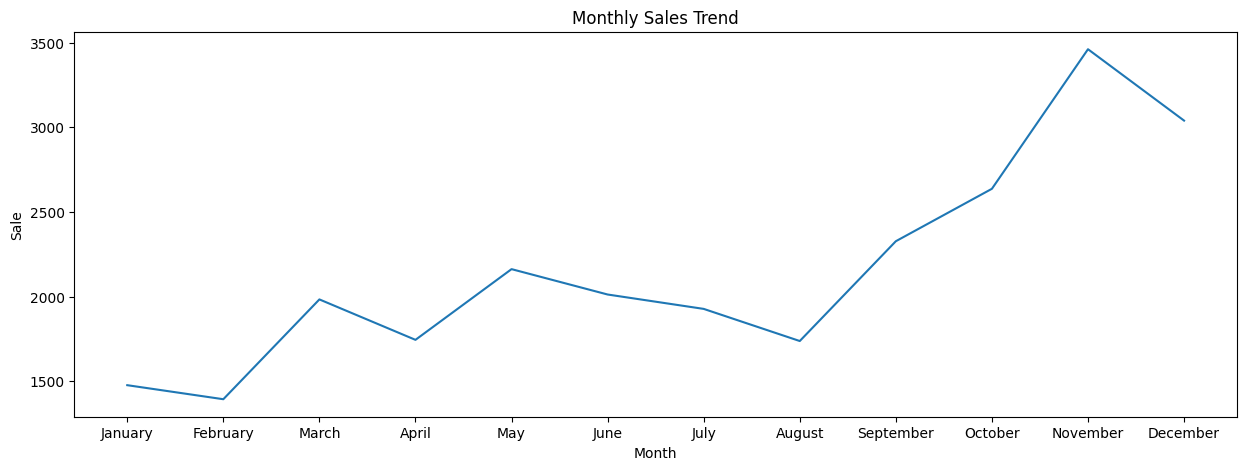

In [6]:
# 1. Create a line plot showing sales trend over months.
# 2. Add:
# o Title
# o X-axis label
# o Y-axis label
# 3. Display the plot.
# df_unique_invoice.head()
plt.figure(figsize=(15, 5))
plt.plot(g1_pivot.index, g1_pivot['InvoiceNo'],)
plt.xlabel('Month')
plt.ylabel('Sale')
plt.title('Monthly Sales Trend')
plt.show()

## Task 2: Scatter Plot ()

In [7]:
df['Quantity'] = df['Quantity'].apply(lambda x: 0 if x<0 else x)

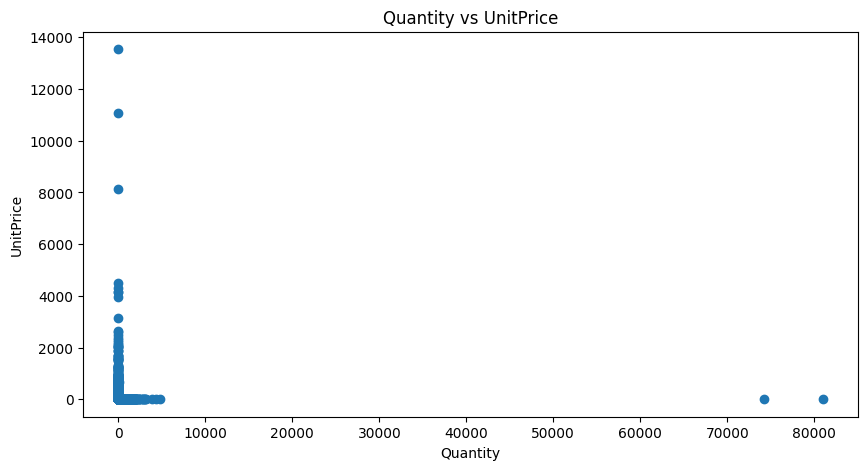

In [8]:
# Task 2: Scatter Plot ()
# Given:
# 1. Create a scatter plot showing relationship between the respective Numerical Columns.
# 2. Add appropriate title and axis labels.
df.head()
# scatter plot can be between UnitPrice and Quantity
df_quant = df[(df['Quantity']>0)&(df['UnitPrice']>0)] # unitPrice and quantity can not be negative
plt.figure(figsize=(10, 5))
plt.scatter(df_quant['Quantity'], df_quant['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Quantity vs UnitPrice')
plt.show()

The above graph states that there are few outliers having quantiy more than 700000. For more clear observation we will plot the graph under this outlier limit

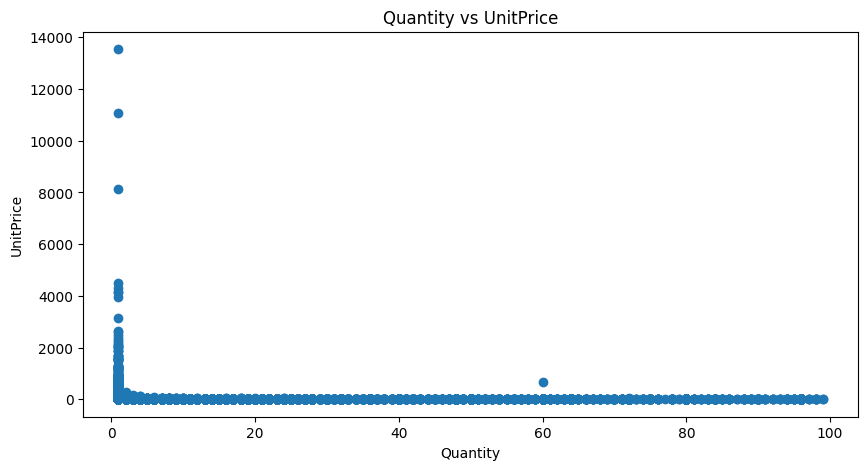

In [9]:
# scatter plot can be between UnitPrice and Quantity Outliers removed
df_quant = df[(df['Quantity']>0)&(df['UnitPrice']>0) & (df['Quantity']<100)] # unitPrice and quantity can not be negative
plt.figure(figsize=(10, 5))
plt.scatter(df_quant['Quantity'], df_quant['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Quantity vs UnitPrice')
plt.show()

Above graph shows the learning trend overall, but for few items higher the price quantity is less

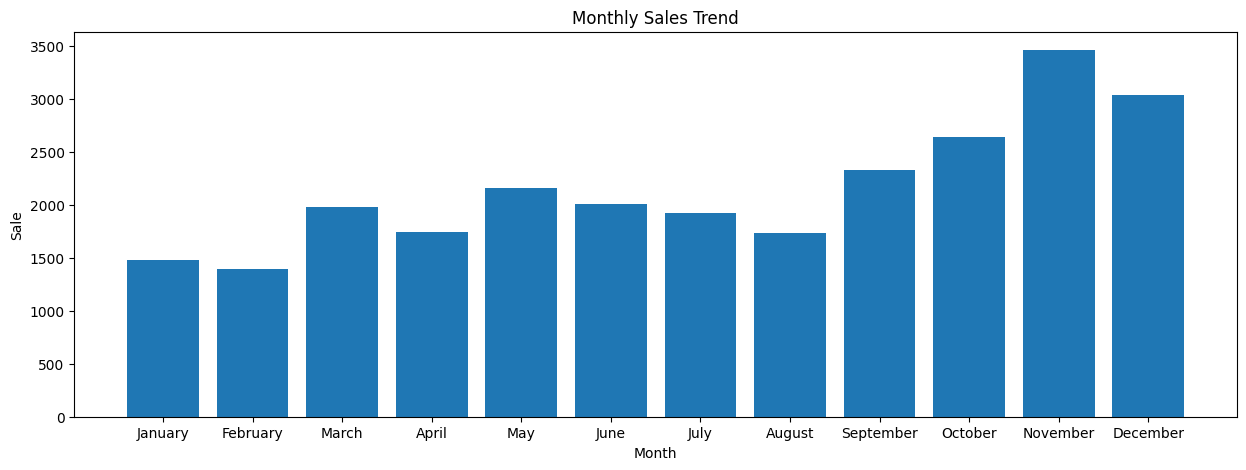

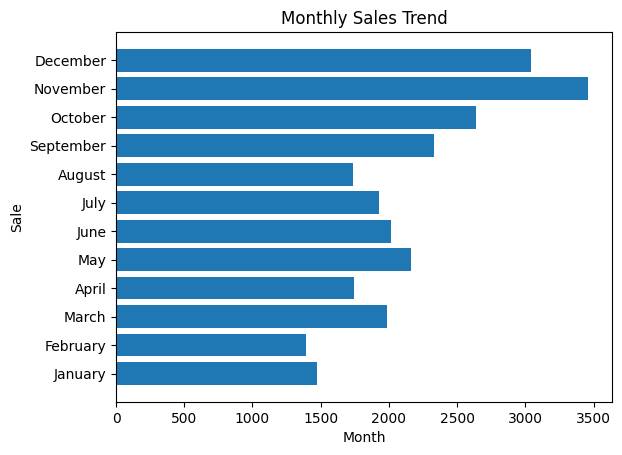

In [10]:
# Task 3: Bar Plot ()
# Given: Kaggle Dataset
# 1. Create a vertical bar chart of column.
# 2. Create a horizontal bar chart for the same data.
# 3. Add titles and labels for both plots.
plt.figure(figsize=(15, 5))
plt.bar(g1_pivot.index, g1_pivot['InvoiceNo'],)
plt.xlabel('Month')
plt.ylabel('Sale')
plt.title('Monthly Sales Trend')
plt.show()

plt.barh(g1_pivot.index, g1_pivot['InvoiceNo'],)
plt.xlabel('Month')
plt.ylabel('Sale')
plt.title('Monthly Sales Trend')
plt.show()

## Task 4: Multiple Bar Plot ()

In [35]:
# Task 4: Multiple Bar Plot ()
# 1. Create a multiple bar chart comparing sales of Different Years .
# 2. Use proper bar width and alignment.
# 3. Add legend, title, and axis labels.

df.InvoiceDateYear.unique()
g4_pivot = df_unique_invoice.pivot_table(index='InvoiceDateMonth', aggfunc='count', values='InvoiceNo', columns='InvoiceDateYear', sort=False, fill_value=0)
g4_pivot

InvoiceDateYear,2011,2010
InvoiceDateMonth,,
January,1476,0
February,1393,0
March,1983,0
April,1744,0
May,2162,0
June,2012,0
July,1927,0
August,1737,0
September,2327,0


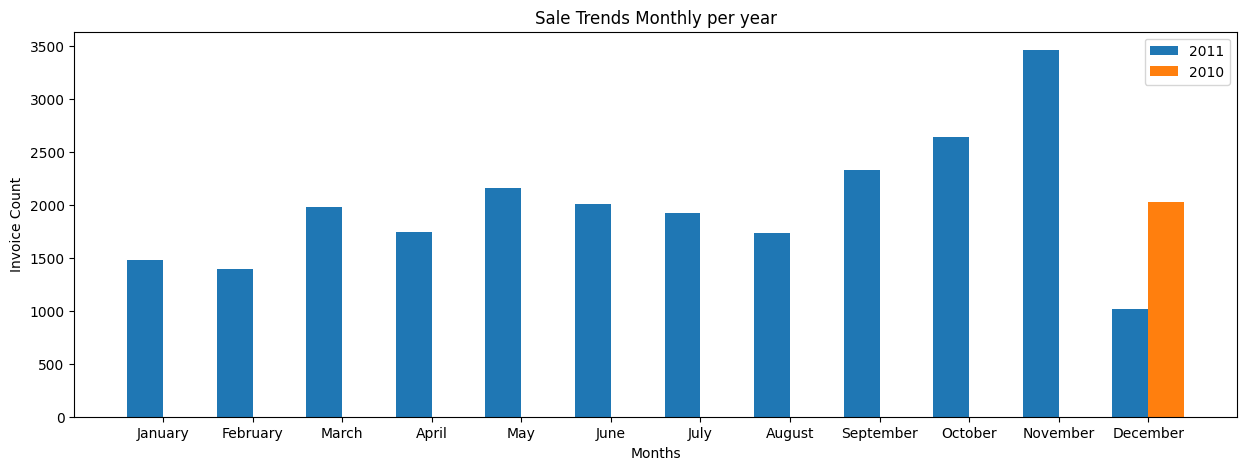

In [ ]:
import numpy as np
# Categories on x axis - months
# values are count of invoices wrt to yrs

months = g4_pivot.index
yrs = list(g4_pivot.columns)
            
# bar width
w, x = 0.4, np.arange(len(months))
plt.figure(figsize=(15,5))
plt.bar(x - w/2, g4_pivot[yrs[0]], w, label=yrs[0])
plt.bar(x + w/2, g4_pivot[yrs[1]], w, label=yrs[1])

plt.xticks(x, months)
plt.ylabel('Invoice Count')
plt.xlabel('Months')
plt.title('Sale Trends Monthly per year')
plt.legend()
plt.show()

## Task 5: Stacked Bar Chart ()

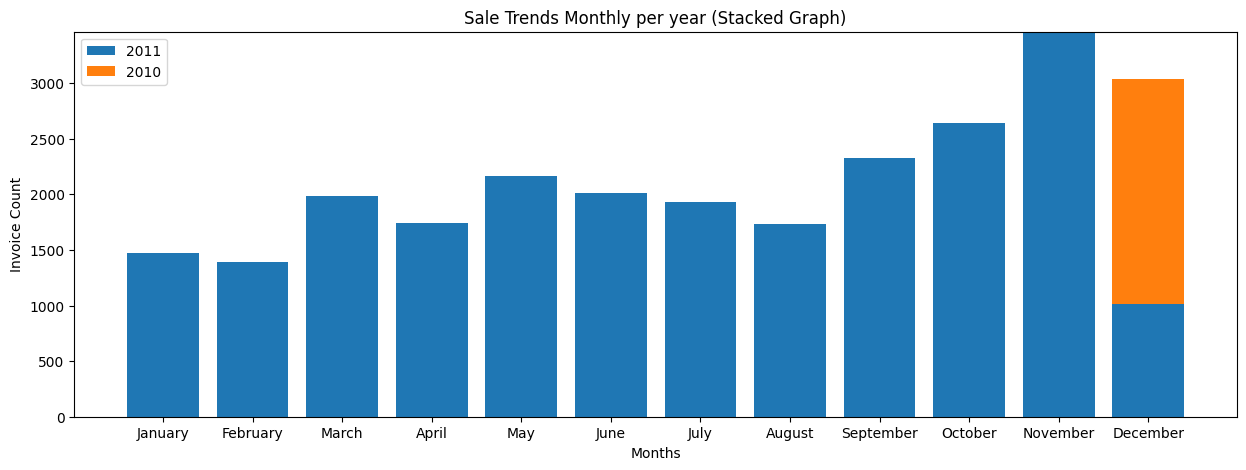

In [41]:
# Task 5: Stacked Bar Chart ()
# Given:
# Create a stacked bar chart showing as per columns knowledge you should go with.
# 1. Add legend and labels.
months = g4_pivot.index
yrs = list(g4_pivot.columns)
            
plt.figure(figsize=(15,5))
plt.bar(months, g4_pivot[yrs[0]],  label=yrs[0])
plt.bar(months, g4_pivot[yrs[1]],  bottom=g4_pivot[yrs[0]],  label=yrs[1])

plt.ylabel('Invoice Count')
plt.xlabel('Months')
plt.title('Sale Trends Monthly per year (Stacked Graph)')
plt.legend()
plt.show()

## Task 6: Histogram (Marks Distribution)

In [68]:
# Task 6: Histogram (Marks Distribution)
# 1. Create a histogram showing Numeric distribution.
# 2. Choose appropriate number of bins.
# 3. Add title and axis labels.

df_quant['TotalAmount'] = df_quant['Quantity'] * df_quant['UnitPrice']
df_quant.head()
df_quant['TotalAmount'].max()
df_quant['TotalAmount'].min()
np.percentile(df_quant['TotalAmount'], [25, 50, 75, 95])
df_quant[df_quant['TotalAmount']>1000]



C:\Users\palak\AppData\Local\Temp\ipykernel_7924\1099133247.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_quant['TotalAmount'] = df_quant['Quantity'] * df_quant['UnitPrice']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDateField,InvoiceDateMonthYear,InvoiceDateMonth,InvoiceDateMonthNumber,InvoiceDateYear,TotalBalance,TotalAmount
4298,541220,22838,3 TIER CAKE TIN RED AND CREAM,96,1/14/2011 14:11,12.75,14156.0,EIRE,2011-01-14 14:11:00,January 2011,January,1,2011,1224.00,1224.00
87569,545320,22838,3 TIER CAKE TIN RED AND CREAM,96,3/1/2011 14:47,12.75,14156.0,EIRE,2011-03-01 14:47:00,March 2011,March,3,2011,1224.00,1224.00
91723,546558,M,Manual,1,3/15/2011 9:50,2583.76,NaN,Hong Kong,2011-03-15 09:50:00,March 2011,March,3,2011,2583.76,2583.76
98886,546328,M,Manual,1,3/11/2011 10:19,1687.17,14911.0,EIRE,2011-03-11 10:19:00,March 2011,March,3,2011,1687.17,1687.17
98887,546329,M,Manual,1,3/11/2011 10:22,1687.17,14911.0,EIRE,2011-03-11 10:22:00,March 2011,March,3,2011,1687.17,1687.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507210,538063,22830,UTILTY CABINET WITH HOOKS,96,12/9/2010 13:44,19.94,18102.0,United Kingdom,2010-12-09 13:44:00,December 2010,December,12,2010,1914.24,1914.24
508434,537659,22833,HALL CABINET WITH 3 DRAWERS,72,12/7/2010 16:43,32.69,18102.0,United Kingdom,2010-12-07 16:43:00,December 2010,December,12,2010,2353.68,2353.68
526578,539750,22423,REGENCY CAKESTAND 3 TIER,79,12/21/2010 15:40,25.49,NaN,United Kingdom,2010-12-21 15:40:00,December 2010,December,12,2010,2013.71,2013.71
528067,539856,M,Manual,1,12/22/2010 14:41,1298.40,NaN,United Kingdom,2010-12-22 14:41:00,December 2010,December,12,2010,1298.40,1298.40


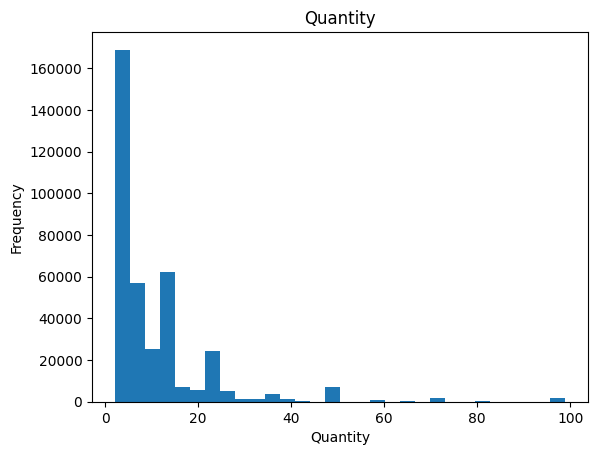

In [79]:
# plt.hist(df_quant['TotalAmount'][(df_quant['UnitPrice']<=100)&(df_quant['Quantity']<=10)], bins=30)
plt.hist(df_quant['Quantity'][(df_quant['Quantity']>1)], bins=30)
plt.ylabel('Frequency')
plt.xlabel('Quantity')
plt.title('Quantity')
plt.show()

## Task 7: Pie Chart (Market Share)

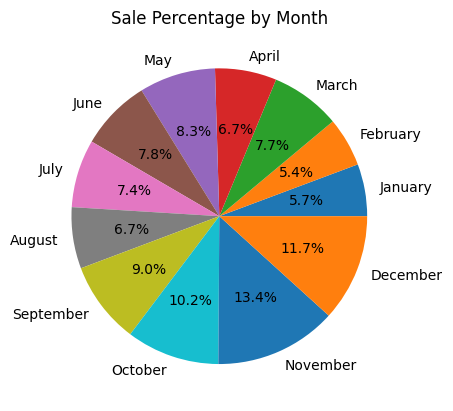

In [82]:
# Given:
# 1. Create a pie chart representing category share.
# 2. Display percentage values.
# 3. Add title.

# Sale percentage by month
plt.pie(g1_pivot['InvoiceNo'], labels=g1_pivot.index, autopct='%1.1f%%')
plt.title("Sale Percentage by Month")
plt.show()